In [1]:
!pip install spectral

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 1.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for spectral: filename=spectral-0.25-py3-none-any.whl size=242940 sha256=10635141eb7affd924a35c2920c1f289459b1c11e168fdc2e5176145a3754beb
  Stored in directory: /root/.cache/pip/wheels/0e/86/f2/f215d05f41af2059193a22339d0b694c3e2ca6bbb6fe58bd5f
Successfully built spectral


In [2]:
#Checking for successful installation and verison
import spectral
print(spectral.__version__)

0.25


*****Hyperspectral data**** usually consists of 2 files:*
1. something.hdr (header file)
2. something.img (image file)
**header file** contains information about the data set such as "number of rows, columns and spectral bands, data type and wavelength information etc"
**image file** contains the actual pixel data of the image
3. .mat files (matlab data set)

In [3]:
file_path = "/kaggle/input/datasets/armageddon47/hyperspectral-data-pavia-university"
import os
for root,direc,files in os.walk(file_path):
    for file in files:
        print(os.path.join(root, file)) 
#os.path.join helps create the file path for each of the files in the data set

/kaggle/input/datasets/armageddon47/hyperspectral-data-pavia-university/Hyperspectral data (pavia university)/PaviaU_gt.mat
/kaggle/input/datasets/armageddon47/hyperspectral-data-pavia-university/Hyperspectral data (pavia university)/PaviaU.mat


1. .mat contains matlab data, which can be accessed by scipy.io (gt_mat contains ground truth i.e. each pixel in .mat belongs to which class and .mat contains pixel values
2. .hdr and .img or .hdr and .dat file can be accessed by spectra


In [4]:
import scipy.io
data = scipy.io.loadmat("/kaggle/input/datasets/armageddon47/hyperspectral-data-pavia-university/Hyperspectral data (pavia university)/PaviaU.mat")
print(data.keys()) 
#.mat fiel can contain multiple variables inside, we need hyperspectral cube
#.key() gives the name of variable inside the data
#hyperspectral cube is stored under paviaU

dict_keys(['__header__', '__version__', '__globals__', 'paviaU'])


In [5]:
data["paviaU"].shape #analyzing the shape of paviaU

(610, 340, 103)

1. (610, 340, 103) is a 3D array
2. 610 rows, 340 columns and 103 spectral bands
3. 610 × 340 gives spatila dimension (location of pixels), 103 gives spectral dimension (pixel value)
each spectral band is a 2D matrix with 610 rows and 340 columns corresponding to a specific wavelength


In [6]:
gt = scipy.io.loadmat("/kaggle/input/datasets/armageddon47/hyperspectral-data-pavia-university/Hyperspectral data (pavia university)/PaviaU_gt.mat")
print(gt.keys())
print(gt["paviaU_gt"].shape)

dict_keys(['__header__', '__version__', '__globals__', 'paviaU_gt'])
(610, 340)


In [7]:
import numpy as np
gt_array = np.array(gt['paviaU_gt'])
print(gt_array)
#each value in a array represents a class, for example 0 represents background, while other values show other class in the image

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [2 2 2 ... 0 0 0]
 [2 2 2 ... 0 0 0]
 [2 2 2 ... 0 0 0]]


In [8]:
#unique classes in gt
print(np.unique(gt_array, return_counts=True)) # this shows how many pixels belong to each class

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([164624,   6631,  18649,   2099,   3064,   1345,   5029,   1330,
         3682,    947]))


In [9]:
#hyperspectral cube:
cube = data["paviaU"]

In [10]:
print(cube[0,0,:]) #3D array slicing, ths gives all of the 103 spectral measurements for the pixel at 0,0
print(gt_array[0,0]) #as the ground label is 0, the pixel is classified as background

[ 647  499  464  371  291  319  365  322  296  305  277  219  219  222
  201  162  157  183  204  194  198  216  249  284  294  322  338  342
  336  342  362  365  348  341  324  316  293  274  251  244  263  248
  236  254  255  240  223  203  202  191  185  200  203  181  168  174
  185  187  165  151  144  140  149  169  192  227  287  376  493  633
  763  913 1149 1442 1759 2102 2425 2689 2895 3058 3196 3252 3195 3297
 3542 3550 3537 3545 3514 3477 3468 3433 3408 3420 3416 3335 3256 3226
 3205 3210 3221 3238 3250]
0


In [11]:
#location of thr first non zero (Class) pixel value, [0] speicifes that we only need the first non zero pixel location
np.argwhere(gt_array > 0)[0]

array([ 0, 91])

In [12]:
print(cube[0,91,:])
print(gt_array[0,91]) #class 1

[1447 1113  973 1053 1180 1263 1285 1320 1283 1295 1337 1317 1327 1371
 1404 1430 1461 1470 1494 1519 1523 1542 1590 1608 1587 1606 1631 1637
 1658 1697 1727 1723 1743 1787 1793 1817 1841 1862 1881 1894 1907 1905
 1892 1906 1915 1915 1933 1935 1928 1913 1925 1949 1958 1954 1937 1922
 1939 1949 1945 1951 1957 1963 1973 1955 1914 1925 1956 1953 1978 1978
 1944 1922 1918 1937 1946 1941 1940 1936 1900 1904 1917 1899 1845 1827
 1871 1869 1851 1827 1821 1820 1830 1829 1807 1793 1788 1749 1696 1708
 1714 1698 1660 1643 1610]
1


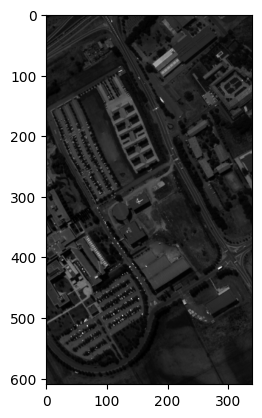

In [13]:
#visualizing each spectral band at a time
import matplotlib.pyplot as plt
plt.imshow(cube[:,:,50], cmap='gray')

In [14]:
#extracting pixel spectra (how each pixel value vaires in all spectral bands)
#plotting spectral signatures of pixels
spectrum  = cube[100, 150, :]
print(spectrum)
print(spectrum.shape)

[ 875 1080 1115  938  929  986  946  894  832  806  766  752  831  891
  885  836  853  864  866  899  917  899  889  873  874  886  888  874
  865  872  885  872  884  917  935  942  947  963  979  966  939  944
  960  975  991  996  986  989  997 1008 1007 1014 1042 1059 1042 1060
 1086 1069 1047 1052 1061 1070 1098 1126 1129 1134 1134 1135 1154 1185
 1220 1232 1233 1223 1236 1273 1296 1311 1340 1349 1351 1359 1380 1382
 1394 1404 1397 1402 1399 1424 1424 1414 1413 1429 1479 1481 1450 1418
 1408 1425 1410 1425 1508]
(103,)


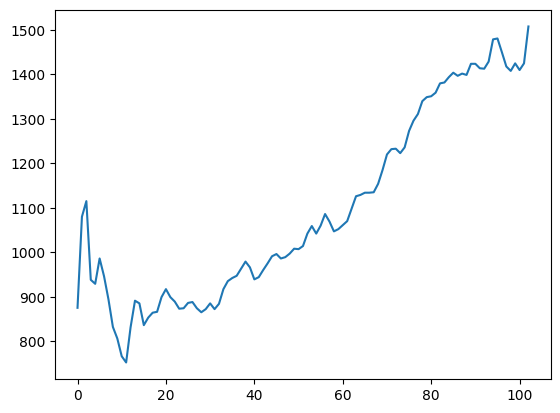

In [15]:
plt.plot(spectrum)
#spectral band number on x axis and spectral values on y axis


each pixel = 103 spectral measurements. This spectral signature acts as the feature vector for our SVM. For SVM, hyperspectral cube needs to be converted into a data set where:1. rows = pixels2. columns = spectral bands/featuresIn this case, spatial dimension is 610×340 = 207400 pixels.we have to make it like 207400 rows and 103 columns/features. So, the new data shape will be 207400 x 103. 


In [16]:
#Standarizing and train/test split of the data
#we first need to remove the background class (0) pixel value from the data

mask = gt_array > 0 #creating a mask using gt_array, only classes other than 0 are useful
x = cube[mask] #applying this mask on cube led to exlusion of all pixels which belonged to class 0 (background)
print(x.shape)

#2D mask converted the 3D cube into 2D array (rows are individual pixels and columns are spectral bands)
#mask removed all those pixel values and their respective spectral bands belonging to class 0

(42776, 103)


In [17]:
#creating labels for each row of x

y = gt_array[mask]
print(y.shape)
print(np.unique(y))

(42776,)
[1 2 3 4 5 6 7 8 9]


In [18]:
#train_test_split
#startify=y helps manage the class imbalance in the data, it helps keep the same percentage of class in both training and testing set

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.75, stratify=y, random_state=101)

print(x_train.shape)
print(x_test.shape)

(32082, 103)
(10694, 103)


In [19]:
#standarizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

In [20]:
#Support vector classification
from sklearn.svm import SVC
svm_std = SVC(kernel="rbf")
svm_std.fit(x_train_std, y_train)
y_pred_std = svm_std.predict(x_test_std)

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred_std))

0.9187394800822891


In [22]:
cm_std = confusion_matrix(y_test, y_pred_std)
cm_std

array([[1569,    9,    7,    0,    0,    6,   24,   43,    0],
       [   0, 4608,    0,   16,    0,   36,    0,    2,    0],
       [  55,    1,  336,    0,    0,    0,    0,  133,    0],
       [   0,   51,    0,  715,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,  333,    1,    0,    2,    0],
       [   4,  305,    0,    1,    0,  940,    0,    7,    0],
       [  79,    0,    0,    0,    0,    0,  252,    1,    0],
       [  26,    4,   53,    0,    0,    3,    0,  835,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,  237]])

In [23]:
print(classification_report(y_test, y_pred_std, zero_division=0))

              precision    recall  f1-score   support

           1       0.91      0.95      0.93      1658
           2       0.93      0.99      0.96      4662
           3       0.85      0.64      0.73       525
           4       0.98      0.93      0.95       766
           5       1.00      0.99      1.00       336
           6       0.95      0.75      0.84      1257
           7       0.91      0.76      0.83       332
           8       0.82      0.91      0.86       921
           9       1.00      1.00      1.00       237

    accuracy                           0.92     10694
   macro avg       0.93      0.88      0.90     10694
weighted avg       0.92      0.92      0.92     10694



PCA: Principal Component analysis
1. dimensionality reduction technique, it transforms each spectral band into new features known as principal components which are arranged heirarchicaly in order of their ability to explain the variance in data.

In [24]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 0.99) #retaining 95% vairance (keeping smallest number of Prinicpal components that describe 95% variance in the data)
x_train_pca = pca.fit_transform(x_train_std) 
x_test_pca = pca.transform(x_test_std)
#fit on training data (fit_transform)
#transform both training and testing data based on what we learned using fitting to avoid
#we cannot fit and transform both x_train and x_test in order to avoid data leakage

In [25]:
print(x_test_pca.shape) #103 columns reduced to only 4
print(pca.explained_variance_ratio_) #each value given is the amount of variance explained by each principal component adding upto 99.16%

(10694, 4)
[0.63195354 0.2929054  0.06300074 0.0041506 ]


**importing support vector classifier (SVC) from sklearn**
1. SVC vs CNN: CNN are data hungry models while the data at hand is of **high dimensionality and low sample size**
2. normal RGB image has pixel values across 3 spectral bands (red,green and blue) while the spectral image has pixel values across many spectral bands resulting in high dimensionality. In a spectral image, each pixel is classified/labelled into a separate class, hence forth there maybe a few pixels belonging to a certain class leading to low sample size. In case of RGB image, the whole image is labelled as one unit.
3.**a plain CNN's** strength is exploiting spatial structure (this pixel looks like its neighbors), while the **SVM approach** you're using here is purely spectral — it's asking "what does this pixel's spectrum look like," independent of its neighbors.

**RBF kernel** computes similarity between two points based on their distance.
* K(x, x') = exp(-gamma * ||x - x'||²)
This value is highest (close to 1) when points are close together, and decays toward 0 as they get farther apart. Gamma controls how fast that decay happens.

In [26]:
svm_pca = SVC(kernel="rbf")
#rbf (radial basis function = distance based similarity) is a non linear function which helps the SVM make complex decisions
#it gives value ranging from 0 to 1 (0 being very far apart and 1 being very identical)

In [27]:
svm_pca.fit(x_train_pca, y_train)

SVC()

In [28]:
y_pred_pca = svm_pca.predict(x_test_pca)

In [29]:
print(accuracy_score(y_pred_pca, y_test))

0.8152234898073686


In [30]:
#confusion matrix is used to see how well a classification model is performing
#it helps see how well the model is predicting each of the class
cm = confusion_matrix(y_test, y_pred_pca)
cm
#each row represents the true class and each column represents the predicted class

array([[1549,    9,   23,    0,    0,    8,   12,   57,    0],
       [   0, 4609,    0,   46,    0,    5,    0,    2,    0],
       [ 123,    1,  173,    0,    0,    0,    1,  227,    0],
       [   0,  101,    0,  664,    0,    1,    0,    0,    0],
       [   0,    0,    0,    0,  333,    1,    0,    2,    0],
       [   5,  980,    0,    1,    1,  265,    0,    5,    0],
       [ 267,    0,    1,    0,    0,    0,   60,    4,    0],
       [  28,    8,   56,    0,    1,    0,    0,  828,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,  237]])

In [31]:
#classification_report per class
print(classification_report(y_test, y_pred_pca, zero_division=0))

              precision    recall  f1-score   support

           1       0.79      0.93      0.85      1658
           2       0.81      0.99      0.89      4662
           3       0.68      0.33      0.44       525
           4       0.93      0.87      0.90       766
           5       0.99      0.99      0.99       336
           6       0.95      0.21      0.34      1257
           7       0.82      0.18      0.30       332
           8       0.74      0.90      0.81       921
           9       1.00      1.00      1.00       237

    accuracy                           0.82     10694
   macro avg       0.86      0.71      0.73     10694
weighted avg       0.83      0.82      0.78     10694



1. row 6 has a total of 267+1+60+4=332 pixels, out of these 332, 267 were labelled as class 1 (wrong prediction)
2. class 1 is asphalt and class 7 is bitumen (both are carbon based, black and used to make pavements and same spectral signature across 103 bands)
3. classification failure isn't always a modeling problem - sometimes it's a fundamental information limit in the pca transforemed features (pca was supposed to capture
4. most of the overall variance was captured by the first 2 components while 3rd only captured 6.3% and 4th only captured 0.4%. the missing variance must contain the useful information to differentiate between class 1 and class 7, hence the poor performance of pca transformed svm.
5. PCA is unsupervised and optimizes for variance, not class separability; it has no knowledge of the labels, so it can discard low-variance directions that happen to be exactly the ones that separate specific classes."

* **Solution**: in such cases, spatial information is the kind of extra information that can help differentiate between 2 very similar classes. real hyperspectral pipeline = spatial information + spectral information

In [32]:
#Polynomial SVM
svm_poly = SVC(kernel="poly", degree=3)
svm_poly.fit(x_train_std, y_train)

SVC(kernel='poly')

In [33]:
y_pred_poly = svm_poly.predict(x_test_std)
print(accuracy_score(y_test, y_pred_poly))

0.8216757060033664


In [34]:
cm_poly = confusion_matrix(y_test, y_pred_poly)
cm_poly

array([[1559,   24,    7,    0,    0,    0,    0,   68,    0],
       [   0, 4635,    0,   22,    0,    4,    0,    1,    0],
       [ 109,    1,  254,    0,    0,    0,    0,  161,    0],
       [   0,   80,    0,  685,    0,    0,    0,    1,    0],
       [   1,    0,    0,    0,  333,    1,    0,    1,    0],
       [   4, 1001,    0,    1,    0,  248,    0,    3,    0],
       [ 328,    0,    0,    0,    0,    0,    0,    4,    0],
       [  27,   24,   31,    0,    0,    3,    0,  836,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,  237]])

In [35]:
print(classification_report(y_test, y_pred_poly, zero_division=0))

              precision    recall  f1-score   support

           1       0.77      0.94      0.85      1658
           2       0.80      0.99      0.89      4662
           3       0.87      0.48      0.62       525
           4       0.97      0.89      0.93       766
           5       1.00      0.99      1.00       336
           6       0.97      0.20      0.33      1257
           7       0.00      0.00      0.00       332
           8       0.78      0.91      0.84       921
           9       1.00      1.00      1.00       237

    accuracy                           0.82     10694
   macro avg       0.80      0.71      0.72     10694
weighted avg       0.82      0.82      0.78     10694



1. Asphalt vs Bitumen problem still persists, It cannot be solved by using different kernels. kernel choice changes how the SVM draws boundaries in feature space, but it can't manufacture separability that isn't there in the underlying data.
2. row 6 (bitumen) under polynomial — 328 misclassified as class 1, 0 correct, same total collapse as your very first (buggy) PCA baseline. RBF recovers this class reasonably well (252/332); polynomial degree-3 fails on it completely, just like PCA did.
3. The separability between these two classes is subtle enough that it needs a kernel flexible enough to capture it (RBF can, cubic polynomial apparently can't) AND needs the full feature space (PCA's variance-based compression throws it away)

***GridSearch (parameter tuning: C and gamma)**
1. C: it controls the tradeoff between margin width and missclassfication tolerance. Large value of C means lesser tolerance and model will try to fit each point correctly (risk of overfitting) while small value of C means higher tolerance to mismatch, simpler boundary and more regularization
2. Gamma: Specifcally in case of rbf it controls how far each point influences. large value of gamma means influence is strictly localized and can lead to wiggly overfit boundary while small value of gamma means influence reaches far (smoother and simpler decision boundary)

* K(x, x') = exp(-gamma * ||x - x'||²) 

3. Low gamma: the decay is slow — even points that are moderately far away still register as "somewhat similar." So each training point's influence on the decision boundary spreads out over a wide region of feature space. The boundary ends up smooth, because it's being shaped by broad neighborhoods of points, not individual outliers.
High gamma: the decay is fast — a point only registers as "similar" to things very close to it. Influence is tightly localized. The boundary can now bend sharply around individual points or small clusters, because each point is essentially only "voting" on its immediate neighborhood.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
              "C": [0.1, 1, 10],
              "gamma": [0.01, 0.1, 1]
             }

In [37]:
svm_grid = GridSearchCV(
    estimator=SVC(kernel="rbf"),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(x_train_std, y_train)

GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]},
             scoring='accuracy')

In [38]:
print(svm_grid.best_params_)
print(svm_grid.best_score_) #CV average

{'C': 10, 'gamma': 0.1}
0.957951499283087


In [39]:
svm_grid = svm_grid.best_estimator_

In [40]:
y_pred_tuned = svm_grid.predict(x_test_std)
print(accuracy_score(y_test, y_pred_tuned))

0.9621282962408827


In [41]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
cm_tuned

array([[1600,    4,    4,    0,    0,    2,   29,   19,    0],
       [   0, 4608,    0,    3,    0,   50,    0,    1,    0],
       [  11,    0,  446,    0,    0,    0,    0,   68,    0],
       [   5,   21,    0,  739,    0,    1,    0,    0,    0],
       [   0,    0,    0,    0,  335,    1,    0,    0,    0],
       [   0,   83,    0,    0,    1, 1167,    0,    6,    0],
       [  34,    0,    0,    0,    0,    0,  298,    0,    0],
       [  26,    2,   33,    0,    0,    1,    0,  859,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,  237]])

In [42]:
print(classification_report(y_test, y_pred_tuned, zero_division=0))

              precision    recall  f1-score   support

           1       0.95      0.97      0.96      1658
           2       0.98      0.99      0.98      4662
           3       0.92      0.85      0.88       525
           4       1.00      0.96      0.98       766
           5       1.00      1.00      1.00       336
           6       0.95      0.93      0.94      1257
           7       0.91      0.90      0.90       332
           8       0.90      0.93      0.92       921
           9       1.00      1.00      1.00       237

    accuracy                           0.96     10694
   macro avg       0.96      0.95      0.95     10694
weighted avg       0.96      0.96      0.96     10694



In [47]:
import shap
background = shap.kmeans(x_train_std, 10)
explainer = shap.KernelExplainer(svm_grid.predict, background)
shap_values = explainer(x_test_std)

  0%|          | 0/10694 [00:00<?, ?it/s]

KeyboardInterrupt: 